In [2]:
from src import utils, functions, hnn, mcmc
from src.sampling import sampling
from src.configs import CONFIGS
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

2025-01-30 16:11:15.327413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738224675.349893 1718080 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738224675.356792 1718080 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-30 16:11:15.382473: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Figure 2 {q, p} phase space plot corresponding to different energy levels.

In [ ]:
config = CONFIGS["LHNN_1DGaussianmixture"]
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture_sin.weights.h5")

initial_state = np.zeros(2)

timegrad_fn = utils.get_timegrad_fn(functions.functions("1D_Gauss_mix"))
states_numgrad, states_lhnn = [], []
for idx in range(9):
    initial_state[1] = 1/3 * (idx+1)
    states_numgrad.append(utils.get_trajectory(timegrad_fn, initial_state=initial_state, dt=0.05, num_lf=200,require_grads=False)[0])
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])


2025-01-29 21:17:21.991087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738156642.021134 1491180 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738156642.032663 1491180 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-29 21:17:22.070496: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1738156647.432760 1491180 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0

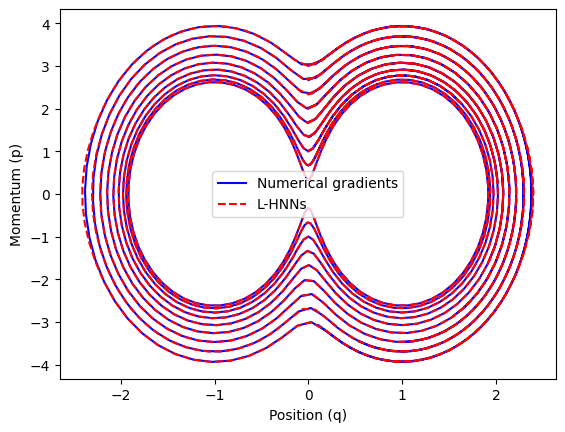

In [2]:
for idx, states in enumerate(states_numgrad):
    if idx == 0:
        plt.plot(states[:100,0], states[:100,1], color="blue", linestyle="-", label="Numerical gradients")
    else:
        plt.plot(states[:100,0], states[:100,1], color="blue", linestyle="-")
for idx, states in enumerate(states_lhnn):
    if idx == 0:
        plt.plot(states[:100,0], states[:100,1], color="red", linestyle="--", label="L-HNNs")
    else:
        plt.plot(states[:100,0], states[:100,1], color="red", linestyle="--")
plt.xlabel("Position (q)")
plt.ylabel("Momentum (p)")
plt.legend()
plt.show()

In [ ]:
hmc_lhnn_1DGaussian = sampling(config_name="LHNN_1DGaussianmixture", sampler_type="HMC", initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.05, 
                        sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_hmc_LHNN_1DGaussianmixture.pkl")
hmc_grad_1DGaussian = sampling(config_name="LHNN_1DGaussianmixture", sampler_type="HMC", initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.05, 
                        sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_hmc_LHNN_1DGaussianmixture.pkl")

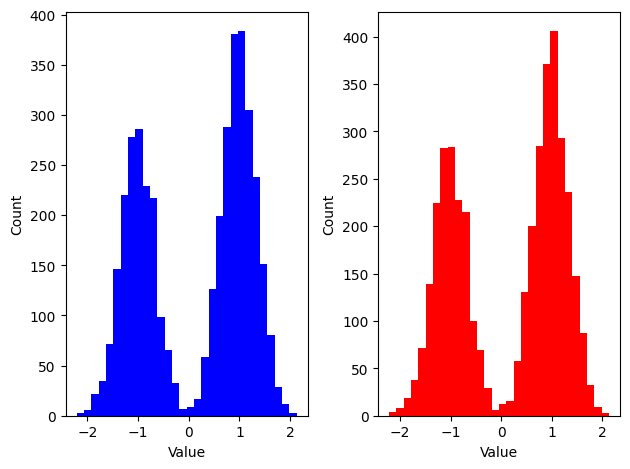

In [6]:
plt.subplot(1,2,1)
plt.hist(hmc_grad_1DGaussian.samples[:,hmc_grad_1DGaussian.burnin:,:].flatten(), color="blue", bins=30, density=False)
plt.xlabel("Value")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(hmc_lhnn_1DGaussian.samples[:,hmc_lhnn_1DGaussian.burnin:,:].flatten(), color="red", bins=30, density=False)
plt.xlabel("Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Figure 3

In [7]:
config = CONFIGS["LHNN_1DGaussianmixture"]
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture_sin.weights.h5")

initial_state = np.zeros(2)

timegrad_fn = utils.get_timegrad_fn(functions.functions("1D_Gauss_mix"))
states_lhnn = []
momentums = [2,-3]
for idx in range(2):
    initial_state[1] = momentums[idx]
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])
states_lhnn_reversed = []
for states in states_lhnn:
    initial_state = states[-1]
    initial_state[1] = -initial_state[1]
    states_lhnn_reversed.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])


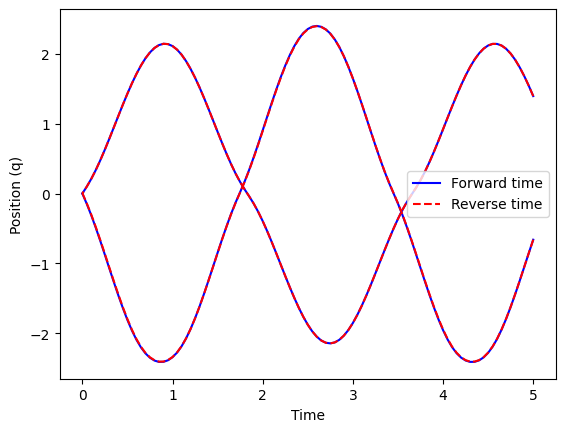

In [8]:
for idx, states in enumerate(states_lhnn):
    if idx == 0:
        plt.plot(np.linspace(0,5,101), states[:,0], color="blue", linestyle="-", label="Forward time")
    else:
        plt.plot(np.linspace(0,5,101), states[:,0], color="blue", linestyle="-")
for idx, states in enumerate(states_lhnn_reversed):
    if idx == 0:
        plt.plot(np.linspace(0,5,101)[::-1], states[:,0], color="red", linestyle="--", label="Reverse time")
    else:
        plt.plot(np.linspace(0,5,101)[::-1], states[:,0], color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Position (q)")
plt.legend()
plt.show()

In [9]:
config = CONFIGS["LHNN_1DGaussianmixture"]
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_1DGaussianmixture_sin.weights.h5")

initial_state = np.zeros(2)
H_func = functions.functions("1D_Gauss_mix")
timegrad_fn = utils.get_timegrad_fn(H_func)
states_numgrad, states_lhnn = [], []
for idx in range(10):
    initial_state[1] = 1/4 * (idx+1)
    states_numgrad.append(utils.get_trajectory(timegrad_fn, initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])
    states_lhnn.append(utils.get_trajectory(lambda x: model.get_gradient(tf.convert_to_tensor(x.reshape(1,-1), dtype=tf.float32)).numpy().flatten(), initial_state=initial_state, dt=0.05, num_lf=100,require_grads=False)[0])

H_numgrad, H_lhnn = [], []
for state_n, state_l in zip(states_numgrad, states_lhnn):
    H_numgrad.append(np.array([H_func(state) for state in state_n]))
    H_lhnn.append(np.array([H_func(state) for state in state_l]))

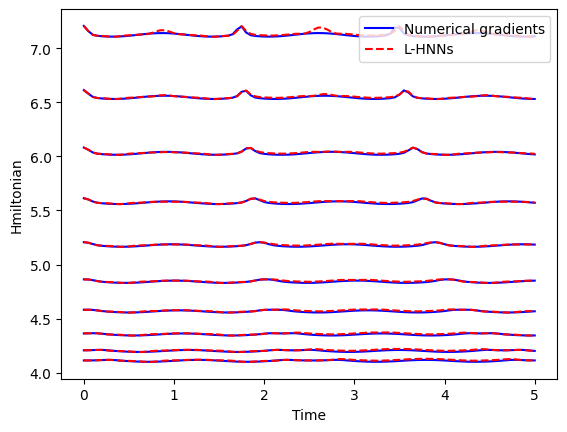

In [11]:
for idx, states in enumerate(states_numgrad):
    if idx == 0:
        plt.plot(np.linspace(0,5,101), H_numgrad[idx], color="blue", linestyle="-", label="Numerical gradients")
    else:
        plt.plot(np.linspace(0,5,101), H_numgrad[idx], color="blue", linestyle="-")
for idx, states in enumerate(states_lhnn):
    if idx == 0:
        plt.plot(np.linspace(0,5,101), H_lhnn[idx], color="red", linestyle="--", label="L-HNNs")
    else:
        plt.plot(np.linspace(0,5,101), H_lhnn[idx], color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Hmiltonian")
plt.legend()
plt.show()

## Tabel 1

In [ ]:
nuts_lhnn_1DGaussian = sampling(config_name="LHNN_1DGaussianmixture", sampler_type="NUTS", initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.05, 
                                    sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_LHNN_1DGaussianmixture.pkl", threshold_nn=np.inf, threshold_lf=1000) 

nuts_grad_1DGaussian = sampling(config_name="LHNN_1DGaussianmixture", sampler_type="NUTS", initial_state=np.array([0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.05, 
                                    sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_nuts_LHNN_1DGaussianmixture.pkl", threshold_lf=1000)


In [ ]:
pd.DataFrame({"ESS per gradient of target density" : np.array([hmc_lhnn_1DGaussian.get_efficient_sample_size()[0][0] / 8000,
                                                               hmc_grad_1DGaussian.get_efficient_sample_size()[0][0] / (8000+500000),
                                                               nuts_lhnn_1DGaussian.get_efficient_sample_size()[0][0] / 8000,
                                                               nuts_grad_1DGaussian.get_efficient_sample_size()[0][0] / (8000+nuts_grad_1DGaussian.numgrad[0])])},
                index=np.array(["L-HNNs in HMC", "Traditional HMC", "L-HNNs in NUTS", "Traditional NUTS"]))

,ESS per gradient of target density
L-HNNs in HMC,0.005871
Traditional HMC,0.000093
L-HNNs in NUTS,0.004023
Traditional NUTS,0.000403


## Figure 4

In [57]:
nuts_lhnn_3Drb_notoem = sampling(config_name="LHNN_3DRosenbrock", sampler_type="NUTS", initial_state=np.array([0,0,0]), num_samples=5000, burnin=1000, chains=1, epsilon=0.025, 
    sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_3Drb_notoem.pkl") # without online error monitoring.

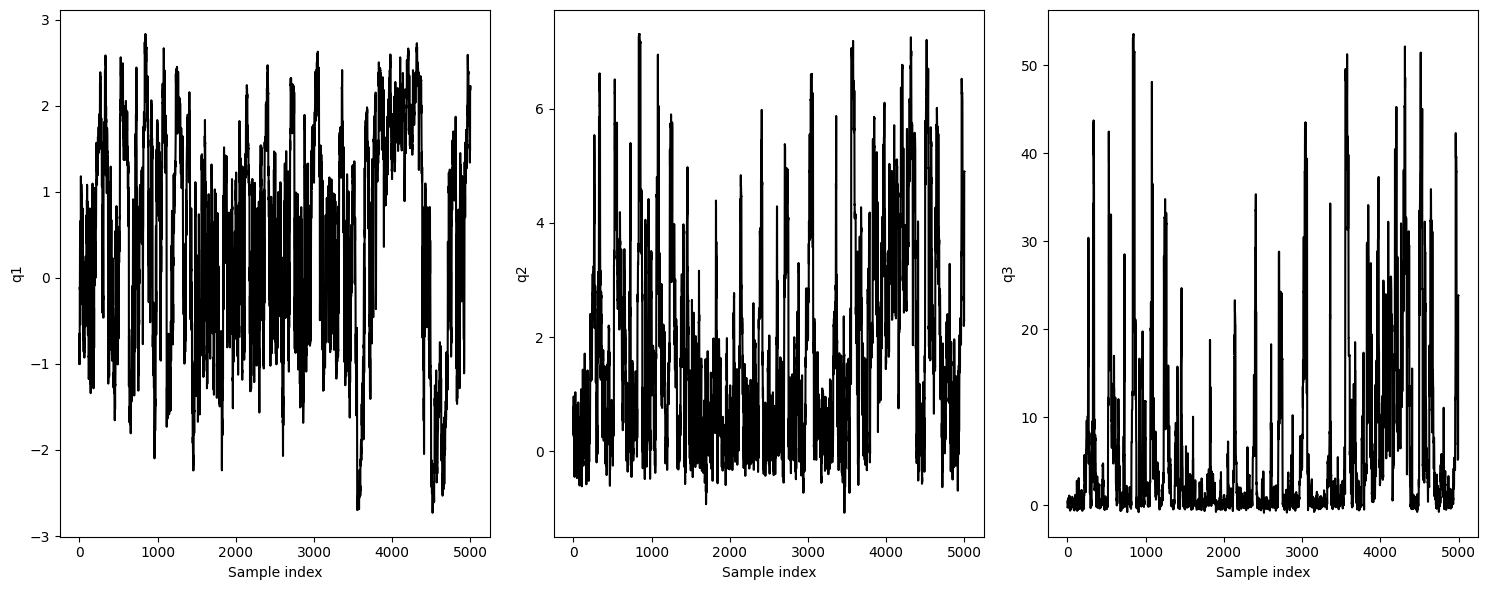

In [58]:
fig, axes = plt.subplots(1,3, figsize=(15, 6))
axes = axes.flatten()
for i in range(3):
    axes[i].plot(np.arange(0,5000), nuts_lhnn_3Drb_notoem.samples[0,:,i], color="black")
    axes[i].set_xlabel("Sample index")
    axes[i].set_ylabel(f"q{i+1}")
plt.tight_layout()
plt.show()


## Figure 5 and 6

In [61]:
nuts_lhnn_3Drb = sampling(config_name="LHNN_3DRosenbrock", sampler_type="NUTS", initial_state=np.array([0,0,0]), num_samples=35000, burnin=1000, chains=1, epsilon=0.025, 
             sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_3Drb.pkl", threshold_nn=10, num_lf=20, threshold_lf=1000) # with online error monitoring.

nuts_hnn_3Drb = sampling(config_name="HNN_3DRosenbrock", sampler_type="NUTS", initial_state=np.array([0,0,0]), num_samples=35000, burnin=1000, chains=1, epsilon=0.025, 
             sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/hnn_nuts_3Drb.pkl", threshold_nn=10, num_lf=20, threshold_lf=1000) # with online error monitoring.

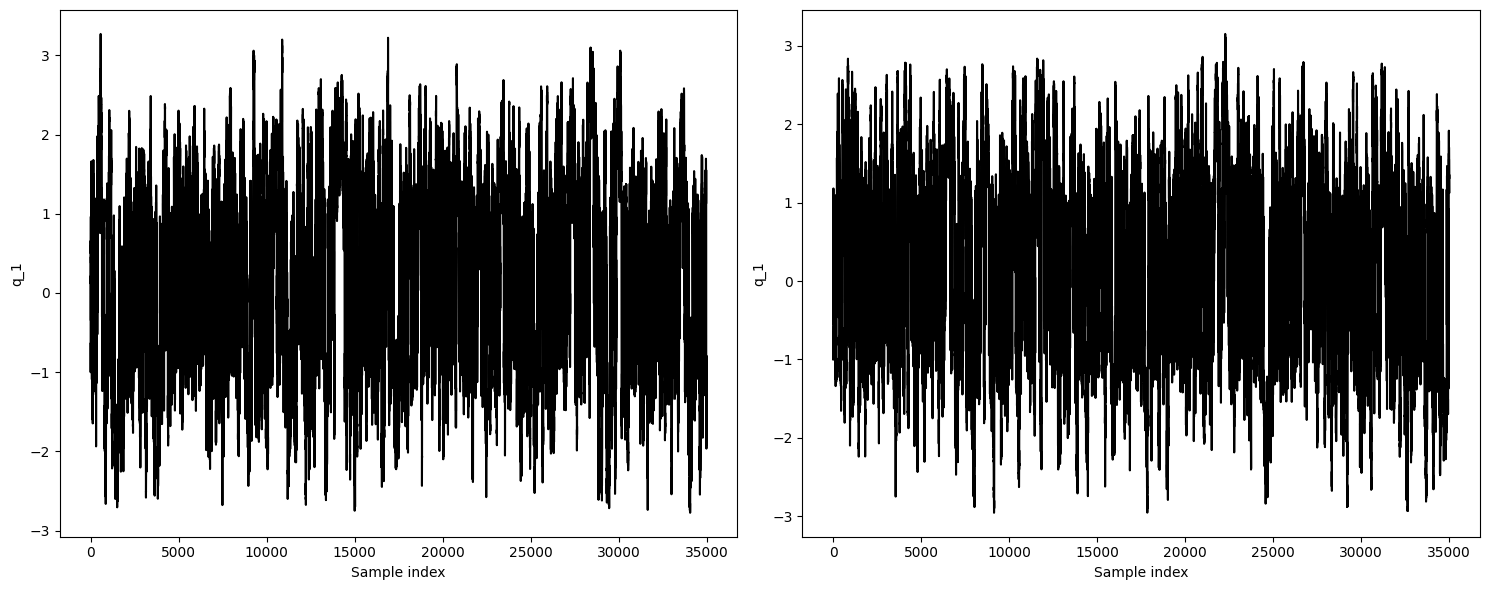

In [65]:
fig, axes = plt.subplots(1,2, figsize=(15,6))
axes = axes.flatten()
axes[0].plot(nuts_hnn_3Drb.samples[0,:,0], color="black")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("q_1")

axes[1].plot(nuts_lhnn_3Drb.samples[0,:,0], color="black")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("q_1")

plt.tight_layout()
plt.show()

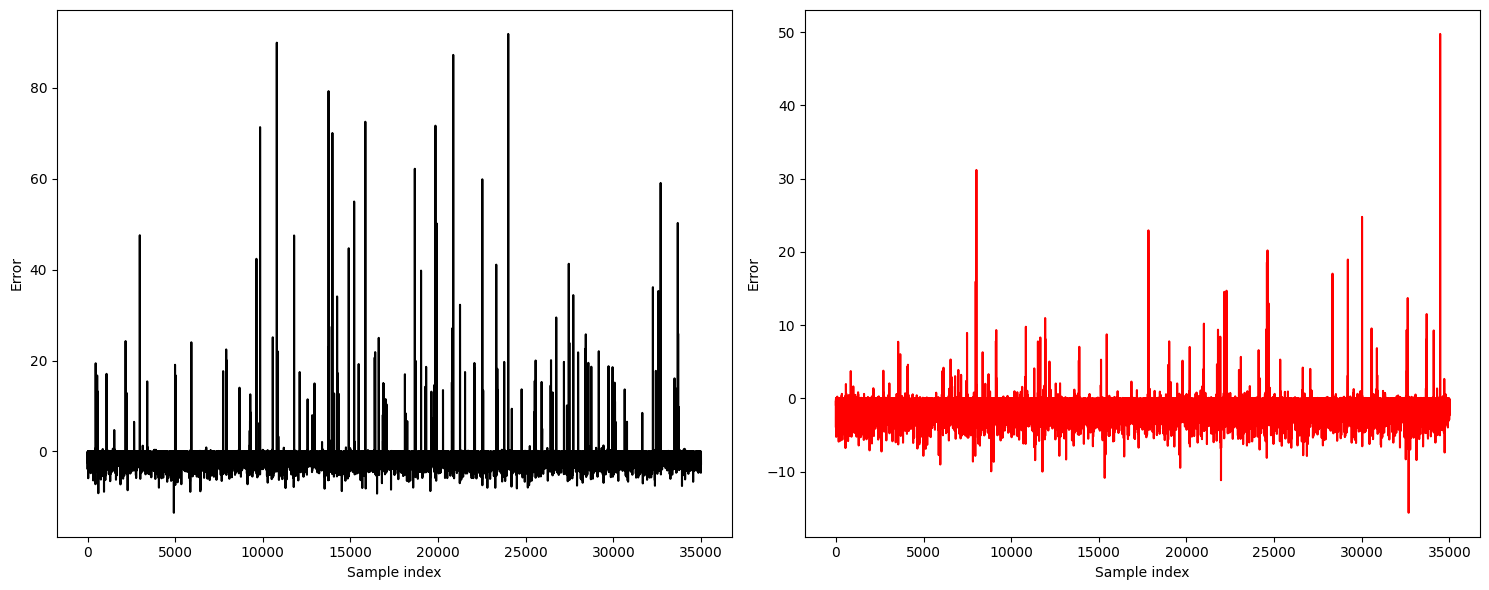

In [66]:
fig, axes = plt.subplots(1,2, figsize=(15,6))
axes = axes.flatten()
axes[0].plot(nuts_hnn_3Drb.monitor[0,:], color="black")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Error")

axes[1].plot(nuts_lhnn_3Drb.monitor[0,:], color="red")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Error")

plt.tight_layout()
plt.show()

## Figure 7 and Table 2

In [8]:
nuts_lhnn_3Drb_T = {}
for T in [100, 150,250]:
    nuts_lhnn_3Drb_T[T] = sampling(config_name=f"LHNN_3DRosenbrock_T{T}", sampler_type="NUTS", initial_state=np.array([0,0,0]), num_samples=125000, burnin=1000, chains=1, epsilon=0.025, 
             sample_path = f"/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_3Drb_T{T}.pkl")

nuts_grad_3Drb = sampling(config_name="LHNN_3DRosenbrock", sampler_type="NUTS", initial_state=np.array([0,0,0]), num_samples=125000, burnin=1000, chains=1, epsilon=0.025, 
             sample_path = f"/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_nuts_3Drb.pkl")

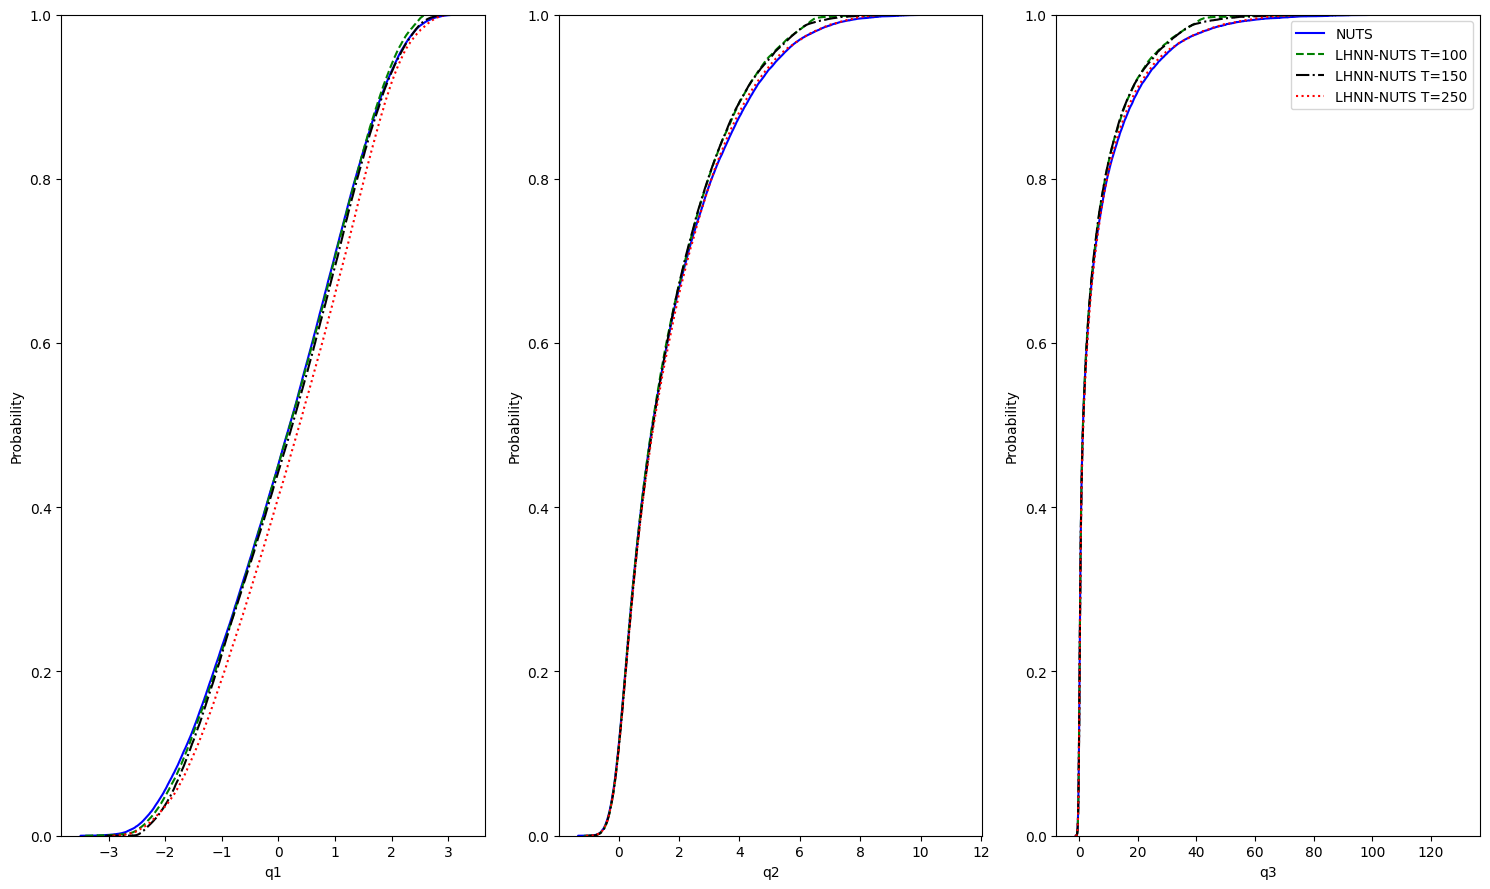

In [72]:
fig, axes = plt.subplots(1,3, figsize=(15,9))
axes = axes.flatten()
for i in range(3):
    axes[i].ecdf(nuts_grad_3Drb.samples[0,nuts_grad_3Drb.burnin:,i], color="blue", linestyle="-", label="NUTS")
    for color, linestyle, T in zip(["green", "black", "red"], ["--", "-.", "dotted"], [100, 150,250]):
        axes[i].ecdf(nuts_lhnn_3Drb_T[T].samples[0,nuts_lhnn_3Drb_T[T].burnin:,i], color=color, linestyle=linestyle, label=f"LHNN-NUTS T={T}")
    axes[i].set_xlabel(f"q{i+1}")
    axes[i].set_ylabel("Probability")
plt.tight_layout()
plt.legend()
plt.show()

In [13]:
def getESStable(samplers, numgrads_training, index=np.array(["LHNN-NUTS", "NUTS"])):
    dim = samplers[0].samples.shape[-1]
    df = pd.DataFrame({f"ESS q{i+1}" : np.array([sampler.get_efficient_sample_size()[0][i] for sampler in samplers]) for i in range(dim)}, index = index)
    df["# of gradients of target density during Evaluation"] = np.array([sampler.numgrad[0] for sampler in samplers])
    df["# of gradients of target density during Training"] = numgrads_training
    df["# of gradients of target density"] = df["# of gradients of target density during Training"] + df["# of gradients of target density during Evaluation"]
    df["Avg. ESS per gradient of target density"] = df[[f"ESS q{i+1}" for i in range(dim)]].mean(axis=1) / df["# of gradients of target density"]
    return df
dft2 = getESStable([nuts_grad_3Drb, nuts_lhnn_3Drb_T[100], nuts_lhnn_3Drb_T[150], nuts_lhnn_3Drb_T[250]], 
                   numgrads_training=np.array([0, 160000,240000,400000]), index=np.array(["NUTS", "LHNN-NUTS T=100", "LHNN-NUTS T=150", "LHNN-NUTS T=250"]))
dft2

,ESS q1,ESS q2,ESS q3,# of gradients of target density during Evaluation,# of gradients of target density during Training,# of gradients of target density,Avg. ESS per gradient of target density
NUTS,1306.865112,1968.871582,2074.035400,13004142.0,0,13004142.0,0.000137
LHNN-NUTS T=100,1378.649414,2084.022217,1990.075684,597691.0,160000,757691.0,0.002399
LHNN-NUTS T=150,1509.695435,2355.791992,1962.166870,945447.0,240000,1185447.0,0.001639
LHNN-NUTS T=250,1547.138672,2156.333984,2327.473389,13840.0,400000,413840.0,0.004858


## Figures 8, 9, 10 and Table 3

In [29]:
# nuts_lhnn_2Dnf = sampling(config_name="LHNN_2DNealsfunnel", sampler_type="NUTS", initial_state=np.array([0,0]), num_samples=25000, burnin=5000, chains=1, epsilon=0.025, 
#              sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_2Dnf.pkl")
# nuts_grad_2Dnf = sampling(config_name="LHNN_2DNealsfunnel", sampler_type="NUTS", initial_state=np.array([0,0]), num_samples=25000, burnin=5000, chains=1, epsilon=0.025, 
#              sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_nuts_2Dnf.pkl")
nuts_lhnn_5DillG = sampling(config_name="LHNN_5DillconditionedGaussian", sampler_type="NUTS", initial_state=np.array([0]*5), num_samples=25000, burnin=5000, chains=1, epsilon=0.025, 
         sample_path="/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_5DillG.pkl")
nuts_grad_5DillG = sampling(config_name="LHNN_5DillconditionedGaussian", sampler_type="NUTS", initial_state=np.array([0]*5), num_samples=25000, burnin=5000, chains=1, epsilon=0.025, 
         sample_path= "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_nuts_5DillG.pkl")
nuts_lhnn_10Drb = sampling(config_name="LHNN_10DRosenbrock", sampler_type="NUTS", initial_state=np.array([0]*10), num_samples=125000, burnin=5000, chains=1, epsilon=0.025, 
         sample_path="/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_10Drb.pkl")
nuts_grad_10Drb = sampling(config_name="LHNN_10DRosenbrock", sampler_type="NUTS", initial_state=np.array([0]*10), num_samples=125000, burnin=5000, chains=1, epsilon=0.025, 
         sample_path= "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_nuts_10Drb.pkl")

In [ ]:
dft3_2Dnf = getESStable([nuts_lhnn_2Dnf, nuts_grad_2Dnf], numgrads_training=np.array([400000,0]))
dft3_2Dnf

In [14]:
dft3_5DillG = getESStable([nuts_lhnn_5DillG, nuts_grad_5DillG], numgrads_training=np.array([400000,0]))
dft3_5DillG

,ESS q1,ESS q2,ESS q3,ESS q4,ESS q5,# of gradients of target density during Evaluation,# of gradients of target density during Training,# of gradients of target density,Avg. ESS per gradient of target density
LHNN-NUTS,20000.0,18144.699219,14207.53125,8023.247559,2472.590088,25000.0,400000,425000.0,0.029576
NUTS,20000.0,17903.156250,14658.81250,8185.424316,2756.694092,9133676.0,0,9133676.0,0.001391


In [15]:
dft3_10Drb = getESStable([nuts_lhnn_10Drb, nuts_grad_10Drb], numgrads_training=np.array([400000,0]))
dft3_10Drb

,ESS q1,ESS q2,ESS q3,ESS q4,ESS q5,ESS q6,ESS q7,ESS q8,ESS q9,ESS q10,# of gradients of target density during Evaluation,# of gradients of target density during Training,# of gradients of target density,Avg. ESS per gradient of target density
LHNN-NUTS,15447.200195,29445.318359,27893.894531,25361.001953,21654.228516,13608.504883,8473.879883,5864.447266,3544.283447,2039.005981,0.0,400000,400000.0,0.038333
NUTS,15951.397461,27579.142578,23974.316406,19612.906250,13089.860352,8263.750977,5217.638672,3198.493652,1654.235718,1227.985352,6761660.0,0,6761660.0,0.001771


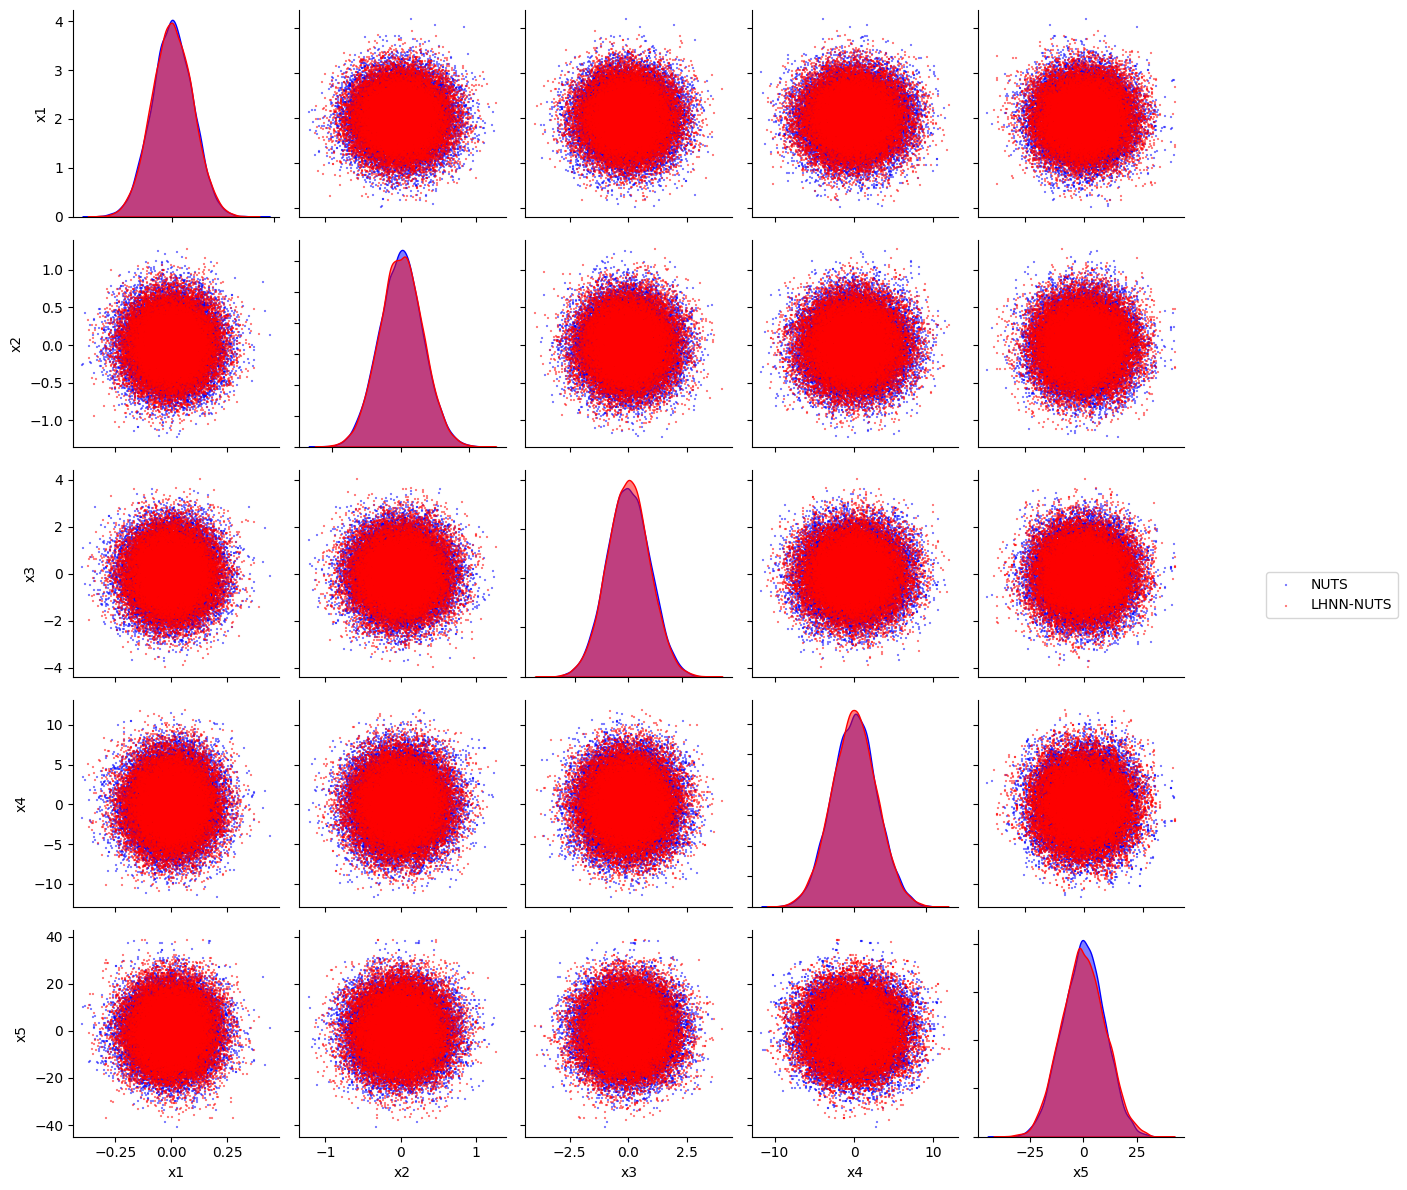

In [41]:
def plotsamples(sampler_grad, sampler_lhnn, dims=None):
    if dims is None:
        dims = list(range(sampler_grad.samples.shape[-1]))
    dim = len(dims)
    fig, axes = plt.subplots(dim, dim, figsize=(12, 12))

    for i, dim_i in enumerate(dims):
        for j, dim_j in enumerate(dims):
            ax = axes[i, j]
            if i == j:
                sns.kdeplot(sampler_grad.samples[0][:, dim_i], ax=ax, color="blue", fill=True, alpha=0.5)
                sns.kdeplot(sampler_lhnn.samples[0][:, dim_i], ax=ax, color="red", fill=True, alpha=0.5)
            else:
                ax.scatter(sampler_grad.samples[0][:, dim_j], sampler_grad.samples[0][:, i], s=1, alpha=0.5, color="blue", marker="+", label="NUTS" if i == 0 and j == 1 else "")
                ax.scatter(sampler_lhnn.samples[0][:, dim_j], sampler_lhnn.samples[0][:, i], s=1, alpha=0.5, color="red", marker="+", label="LHNN-NUTS" if i == 0 and j == 1 else "")
            ax.set_xlabel(f"x{dim_j+1}")
            ax.set_ylabel(f"x{dim_i+1}")
            if j != 0:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            if i != dim-1:
                ax.set_xticklabels([])
                ax.set_xlabel("")  
            ax.spines["right"].set_visible(False)
            ax.spines["top"].set_visible(False)
    fig.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=10)
    fig.tight_layout()
    plt.show()
plotsamples(nuts_grad_5DillG, nuts_lhnn_5DillG)

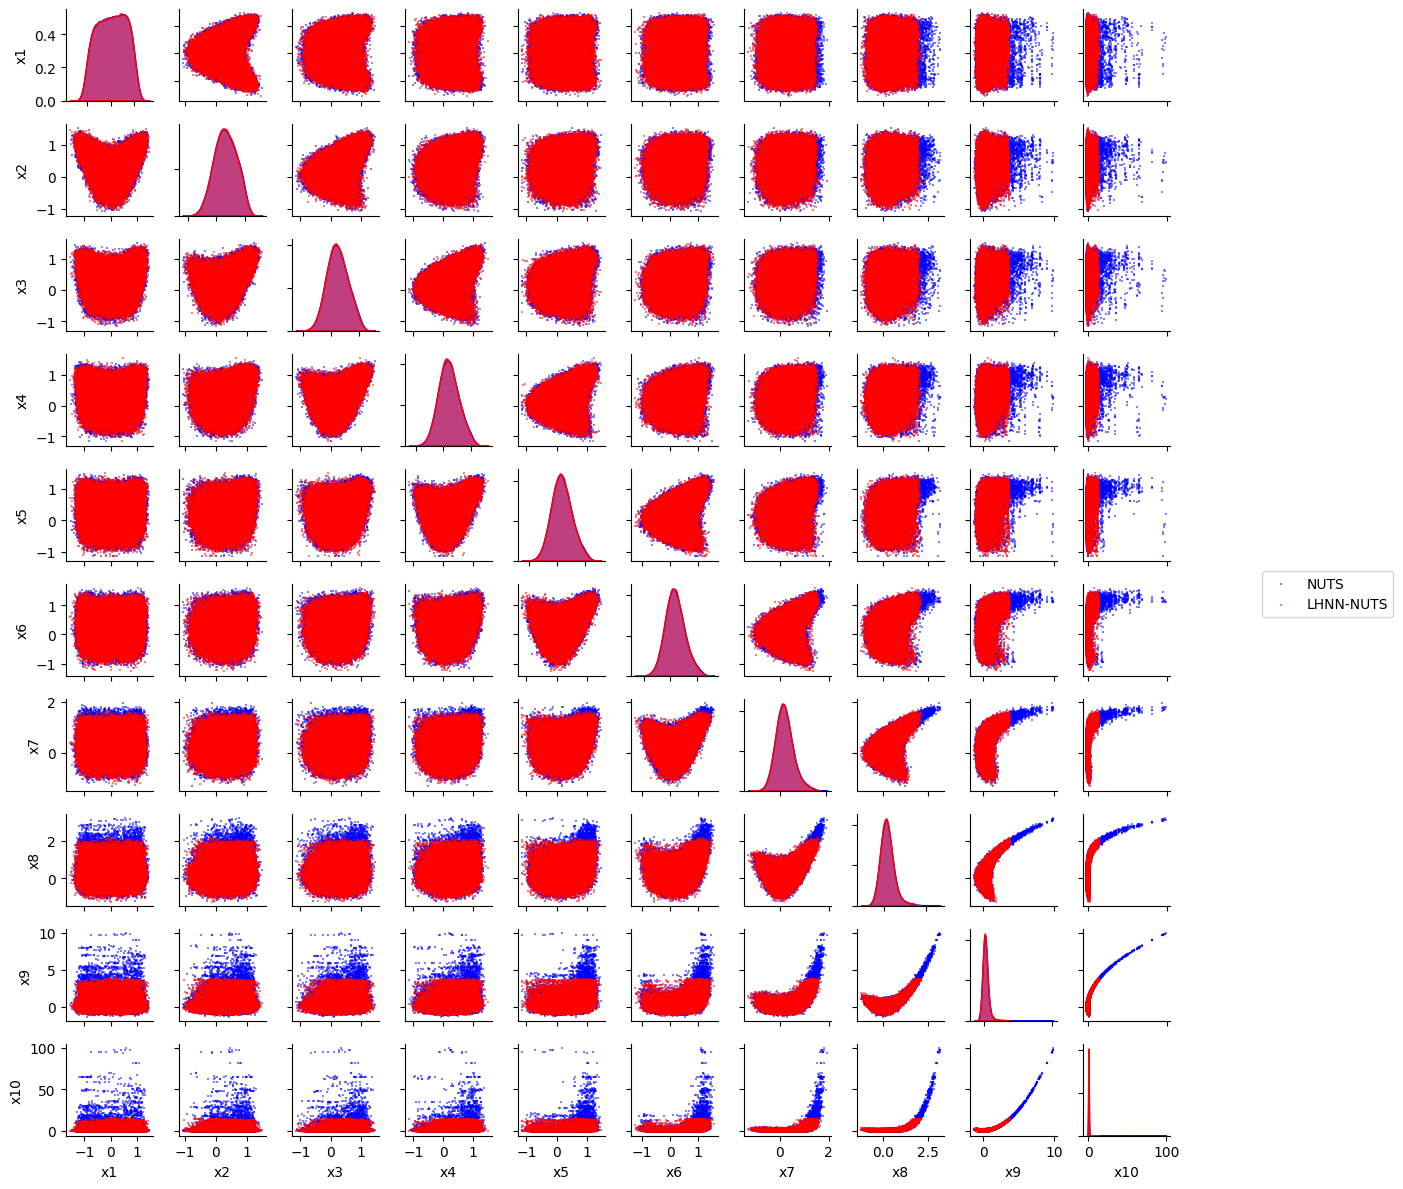

In [37]:
plotsamples(nuts_grad_10Drb, nuts_lhnn_10Drb)

## Figures 11, 12 and Table 4

In [44]:
nuts_lhnn_ac = sampling(config_name="LHNN_AllenCahn", sampler_type="NUTS", initial_state=np.array([0]*25), num_samples=5000, burnin=1000, chains=1, epsilon=0.025, 
         sample_path="/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_ac.pkl")
nuts_grad_ac = sampling(config_name="LHNN_AllenCahn", sampler_type="NUTS", initial_state=np.array([0]*25), num_samples=5000, burnin=1000, chains=1, epsilon=0.025, 
         sample_path= "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_nuts_ac.pkl")
# nuts_lhnn_ellipticpde = sampling(config_name="LHNN_ellipticpde", sampler_type="NUTS", initial_state=np.array([0]*50), num_samples=5000, burnin=1000, chains=1, epsilon=0.025, 
#          sample_path="/home/ycui/Documents/TSRLproject_JPMorgan/samples/lhnn_nuts_ellipticpde.pkl")
# nuts_grad_ellipticpde = sampling(config_name="LHNN_ellipticpde", sampler_type="NUTS", initial_state=np.array([0]*50), num_samples=5000, burnin=1000, chains=1, epsilon=0.025, 
#          sample_path= "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_nuts_ellipticpde.pkl")

In [48]:
dft4_ac = getESStable([nuts_lhnn_ac, nuts_grad_ac], numgrads_training=np.array([10000,0]))
dft4_ac

,ESS q1,ESS q2,ESS q3,ESS q4,ESS q5,ESS q6,ESS q7,ESS q8,ESS q9,ESS q10,...,ESS q20,ESS q21,ESS q22,ESS q23,ESS q24,ESS q25,# of gradients of target density during Evaluation,# of gradients of target density during Training,# of gradients of target density,Avg. ESS per gradient of target density
LHNN-NUTS,322.030365,309.817017,307.597717,301.226379,294.072296,285.988922,284.811707,284.027405,284.895844,276.972076,...,284.014709,294.881927,298.328064,308.353943,324.870117,344.311401,7272.0,10000,17272.0,0.016736
NUTS,293.053497,276.874298,266.299957,262.924622,260.327057,251.274017,243.568542,237.703201,226.090439,219.075302,...,197.248871,208.994217,213.756348,222.998718,250.027756,261.576111,581752.0,0,581752.0,0.000400


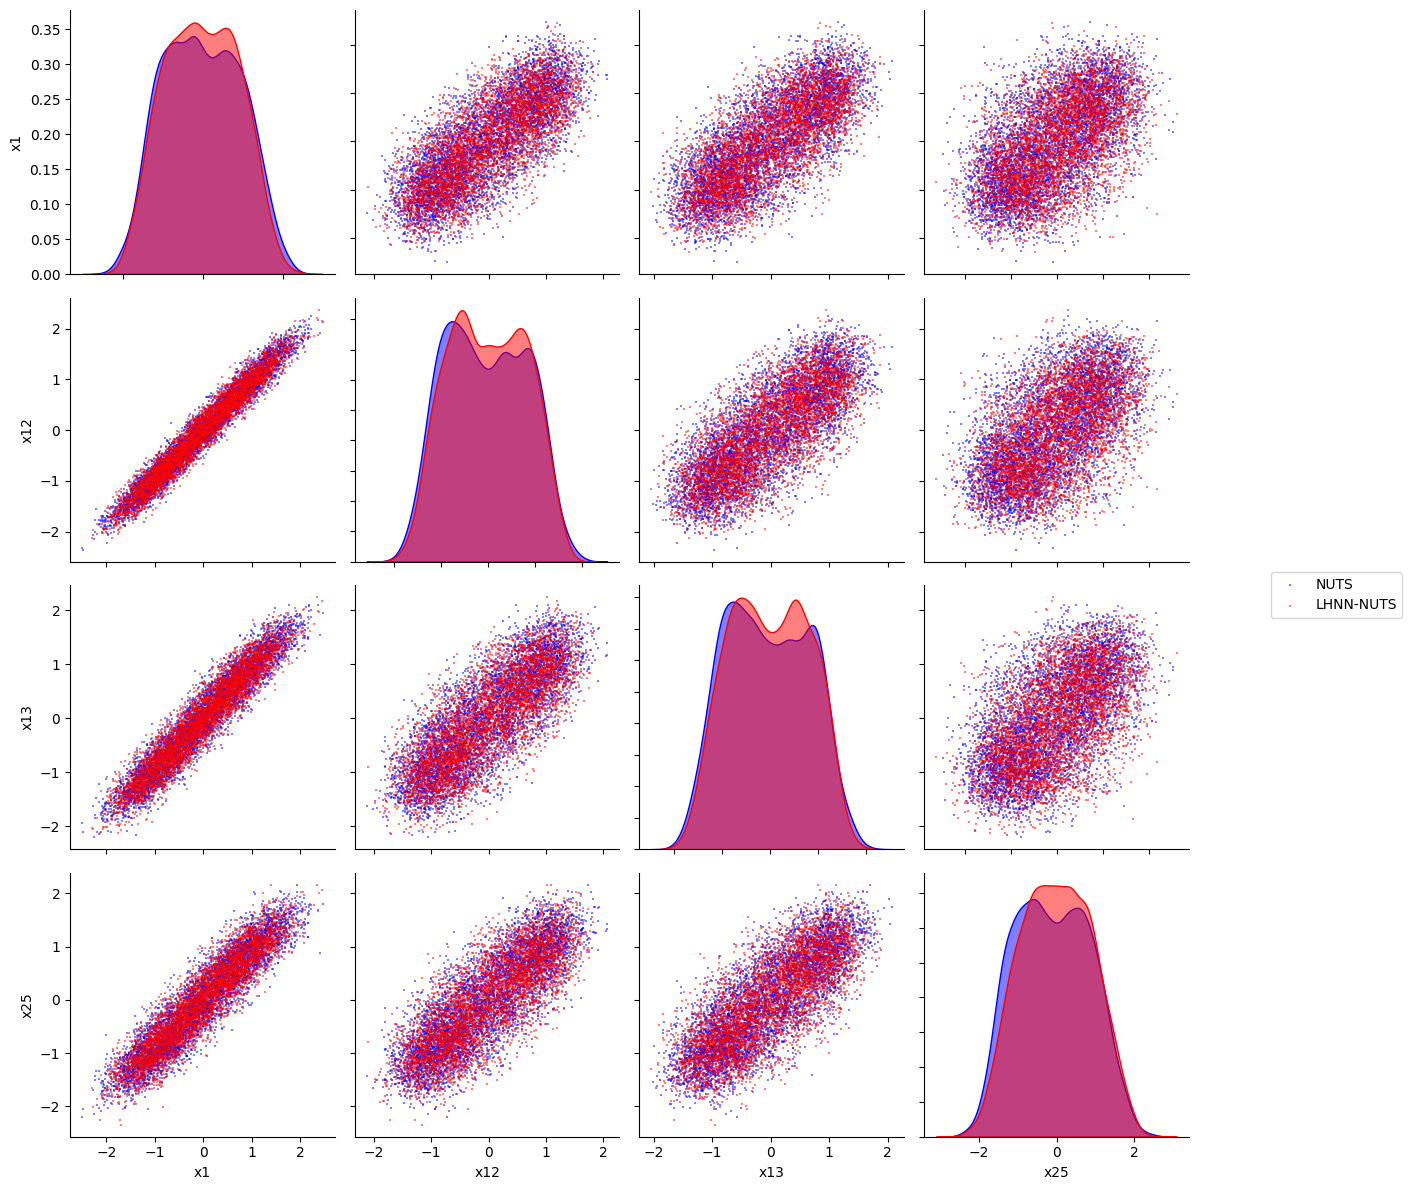

In [42]:
plotsamples(nuts_grad_ac, nuts_lhnn_ac, [0, 11, 12, 24])

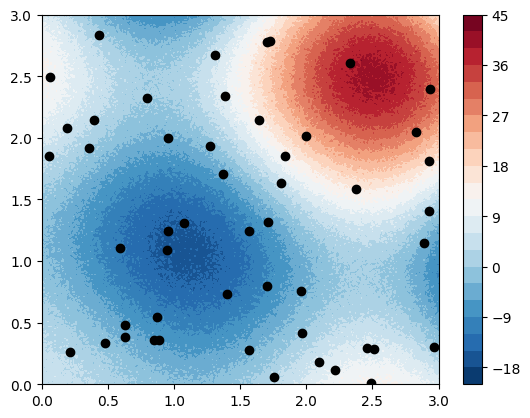

In [41]:
sensor = utils.get_pdesensor()
_, g = utils.get_pdef()
x, y, fg = g
contour = plt.contourf(x, y, fg, levels=20, cmap='RdBu_r') 
plt.scatter(sensor[:,0], sensor[:,1], color="black")
plt.colorbar(contour)
plt.show()

In [42]:
from scipy.interpolate import Rbf
def plotpdeiterp(sensor, sensor_vals, x, y):
    xg, yg = np.meshgrid(x, y, indexing='ij')
    grid_vals = Rbf(sensor[:,0], sensor[:,1], sensor_vals, function='multiquadric')(xg,yg)
    plt.contourf(x, y, grid_vals, levels=20, cmap='RdBu_r') 
    plt.colorbar(contour)
    plt.show()

In [ ]:
plotpdeiterp(sensor, nuts_lhnn_ellipticpde.samples[0].mean(axis=0), x, y)

In [ ]:
plotpdeiterp(sensor, nuts_grad_ellipticpde.samples[0].mean(axis=0), x, y)

In [ ]:
plotpdeiterp(sensor, (nuts_grad_ellipticpde.samples[0]-nuts_lhnn_ellipticpde.samples[0])**2.mean(axis=0), x, y)